# Natural Language Processing Micro Project

In this NLP project we will attempt to classify Yelp Reviews into 1 star or 5 star categories based off the text content in the reviews. 

We will use the [Yelp Review Data Set from Kaggle](https://www.kaggle.com/c/yelp-recsys-2013).

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Data

Each observation in this dataset is a review of a particular business by a particular user.

The "stars" column is the number of stars (1 through 5) assigned by the reviewer to the business. (Higher stars is better.) In other words, it is the rating of the business by the person who wrote the review.

The "cool" column is the number of "cool" votes this review received from other Yelp users. 

All reviews start with 0 "cool" votes, and there is no limit to how many "cool" votes a review can receive. In other words, it is a rating of the review itself, not a rating of the business.

The "useful" and "funny" columns are similar to the "cool" column.


In [2]:
yelp = pd.read_csv('data/yelp.csv')

In [3]:
yelp.head(3)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0


In [4]:
yelp.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   business_id  10000 non-null  str  
 1   date         10000 non-null  str  
 2   review_id    10000 non-null  str  
 3   stars        10000 non-null  int64
 4   text         10000 non-null  str  
 5   type         10000 non-null  str  
 6   user_id      10000 non-null  str  
 7   cool         10000 non-null  int64
 8   useful       10000 non-null  int64
 9   funny        10000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 781.4 KB


In [5]:
yelp.describe()

,stars,cool,useful,funny
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.777500,0.876800,1.409300,0.701300
std,1.214636,2.067861,2.336647,1.907942
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000
75%,5.000000,1.000000,2.000000,1.000000
max,5.000000,77.000000,76.000000,57.000000


In [6]:
#Creating a new column to denote the length of the text
yelp['text length'] = yelp['text'].apply(len)

## EDA

In [7]:
sns.set_style('whitegrid')

Let's create a grid of 5 histograms of text length based off of the star ratings.

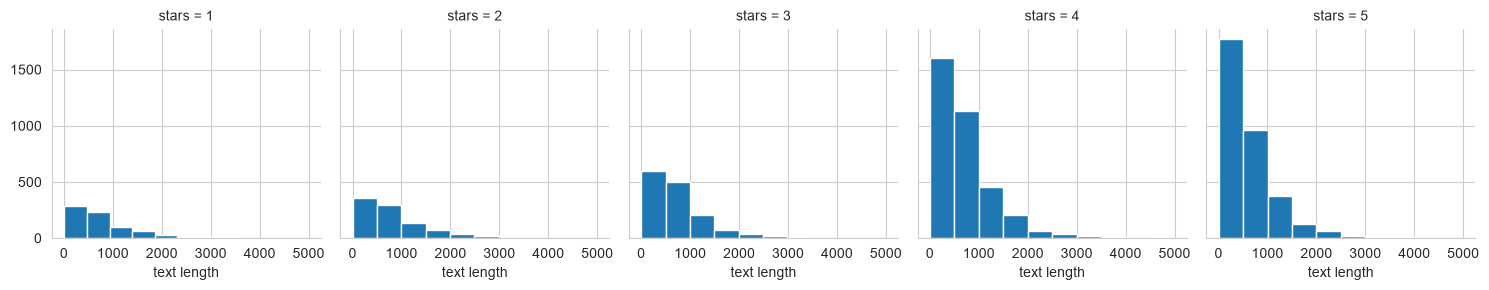

In [8]:
g = sns.FacetGrid(yelp,col='stars')
g.map(plt.hist,'text length')

Visualizing the counts for each rating type. 

<Axes: xlabel='stars', ylabel='count'>

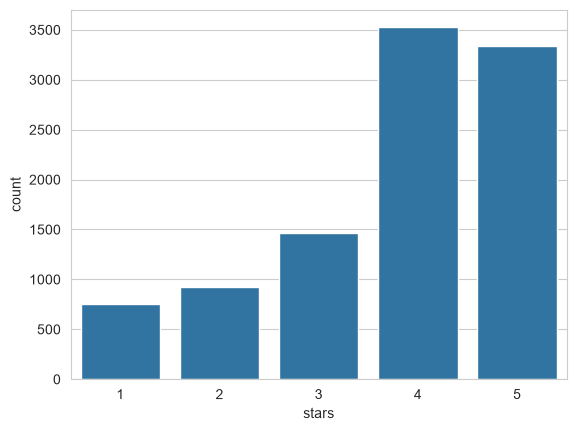

In [9]:
sns.countplot(x='stars',data=yelp)

Grouping the reviews on the basis of the stars.

In [10]:
stars =  yelp.groupby('stars').mean(numeric_only=True)
stars

,cool,useful,funny,text length
stars,,,,
1,0.576769,1.604806,1.056075,826.515354
2,0.719525,1.563107,0.875944,842.256742
3,0.788501,1.306639,0.694730,758.498289
4,0.954623,1.395916,0.670448,712.923142
5,0.944261,1.381780,0.608631,624.999101


Let's check out the correlation between different features for the reviews.

In [11]:
stars.corr()

,cool,useful,funny,text length
cool,1.000000,-0.743329,-0.944939,-0.857664
useful,-0.743329,1.000000,0.894506,0.699881
funny,-0.944939,0.894506,1.000000,0.843461
text length,-0.857664,0.699881,0.843461,1.000000


And visualize this correlation:

<Axes: >

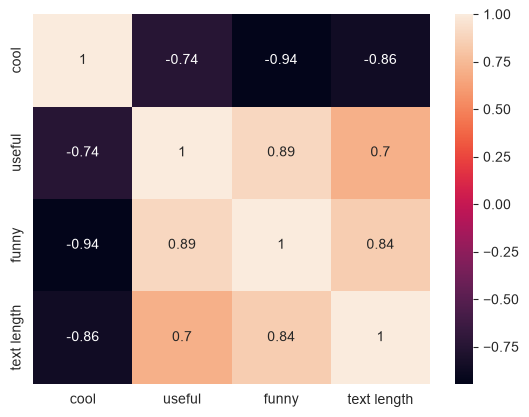

In [12]:
sns.heatmap(stars.corr(),annot=True)

## NLP Classification

Moving on to the actual task: we'll just grab the reviews that were either 1 star or 5 stars, to make life easier in this micro-project.

In [13]:
yelp_class = yelp[(yelp['stars']==1) | (yelp['stars']==5) ]

In [14]:
yelp_class.info()

<class 'pandas.DataFrame'>
Index: 4086 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   business_id  4086 non-null   str  
 1   date         4086 non-null   str  
 2   review_id    4086 non-null   str  
 3   stars        4086 non-null   int64
 4   text         4086 non-null   str  
 5   type         4086 non-null   str  
 6   user_id      4086 non-null   str  
 7   cool         4086 non-null   int64
 8   useful       4086 non-null   int64
 9   funny        4086 non-null   int64
 10  text length  4086 non-null   int64
dtypes: int64(5), str(6)
memory usage: 383.1 KB


Our data will be the text content of the reviews, and we'll try to predict if it's a 1 star or a 5 star review. So let's assign those to our X and y variables.

In [15]:
X = yelp_class['text']
y = yelp_class['stars']

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [17]:
X = cv.fit_transform(X)

### Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [19]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

In [20]:
nb.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[ 521.,2339.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.7,-0.2]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[1,5]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 19183)","[[26., 4., 1.,..., 0., 0., 0.], [35., 7., 0.,..., 1., 0., 1.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 19183)","[[ -8.17, -9.86,-10.78,...,-11.47,-11.47,-11.47], [ -8.92,-10.43,-12.51,...,-11.81,-12.51,-11.81]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19183


### Predictions and Evaluations

In [21]:
preds = nb.predict(X_test)

** Create a confusion matrix and classification report using these predictions and y_test **

In [22]:
from sklearn.metrics import confusion_matrix,classification_report

In [23]:
print(confusion_matrix(y_test,preds))
print(classification_report(y_test,preds))

[[159  69]
 [ 22 976]]
              precision    recall  f1-score   support

           1       0.88      0.70      0.78       228
           5       0.93      0.98      0.96       998

    accuracy                           0.93      1226
   macro avg       0.91      0.84      0.87      1226
weighted avg       0.92      0.93      0.92      1226

